# Health Monitoring System
## Predicting Health Conditions & Heart Beat from Vital Signs

**Project overview**  
This notebook builds a dual-task machine learning system on a 500-row patient vitals dataset.
Two models are trained end-to-end:
- **Classification** — predict health condition (fever / high_bp / low_bp / normal) from temperature, BMI, blood pressure, and room temperature  
- **Regression** — predict resting heart beat (bpm) using the same features plus engineered cardiovascular signals

The classification result is also fed into the regressor as a cascade feature, reflecting the real clinical insight that a patient's diagnosis is the strongest single predictor of their resting heart rate.

---
**Dataset** — 500 patient records, 8 columns, no missing values  
**Target (classification)** — `Condition` (4 classes)  
**Target (regression)** — `Heart Beat (bpm)` (continuous)

## 1. Data loading & cleaning

Import all libraries upfront in a single cell.  
Keeping imports together makes dependencies visible at a glance and avoids re-import clutter throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score,
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.preprocessing import label_binarize

print("All libraries imported successfully.")

All libraries imported successfully.


### 1.1 Load data

Read the CSV with `ISO-8859-1` encoding to handle any special characters in column names (e.g. the degree symbol in `Temperature (°C)`).

In [2]:
data = pd.read_csv('health_data.csv', encoding='ISO-8859-1')
print(f"Dataset loaded — {data.shape[0]} rows, {data.shape[1]} columns")
data.head()

Dataset loaded — 500 rows, 8 columns


,Temperature (°C),BMI,Systolic BP (mmHg),Diastolic BP (mmHg),Heart Beat (bpm),Condition,Room Temperature (°C),Season
0,36.9,29.0,136,119,67,normal,19.9,spring
1,39.8,25.7,101,83,59,low_bp,23.7,spring
2,38.7,21.2,151,109,82,high_bp,26.6,autumn
3,38.0,31.3,169,108,101,high_bp,21.0,spring
4,35.8,28.7,177,110,85,high_bp,25.7,autumn


### 1.2 Shape, types & missing values

Before any analysis, confirm the data types are correct and check for nulls.  
All 8 columns should be non-null. The `Condition` and `Season` columns are `object` (string) — everything else is numeric.

In [3]:
print("Shape:", data.shape)
print()
print(data.info())
print()
print("Missing values per column:")
print(data.isnull().sum())

Shape: (500, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Temperature (°C)       500 non-null    float64
 1   BMI                    500 non-null    float64
 2   Systolic BP (mmHg)     500 non-null    int64  
 3   Diastolic BP (mmHg)    500 non-null    int64  
 4   Heart Beat (bpm)       500 non-null    int64  
 5   Condition              500 non-null    object 
 6   Room Temperature (°C)  500 non-null    float64
 7   Season                 500 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 31.4+ KB
None

Missing values per column:
Temperature (°C)         0
BMI                      0
Systolic BP (mmHg)       0
Diastolic BP (mmHg)      0
Heart Beat (bpm)         0
Condition                0
Room Temperature (°C)    0
Season                   0
dtype: int64


### 1.3 Statistical summary

`describe()` gives a quick sense of range and spread.  
- `Temperature` ranges 35–40°C — consistent with normal to high-fever range  
- `Systolic BP` ranges 90–179 mmHg — covers hypotension to hypertension  
- `Heart Beat` is the regression target; range and std will determine how hard the regression task is

In [4]:
data.describe().round(2)

,Temperature (°C),BMI,Systolic BP (mmHg),Diastolic BP (mmHg),Heart Beat (bpm),Room Temperature (°C)
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,37.49,24.64,134.22,89.09,83.49,23.91
std,1.49,5.71,26.19,17.33,19.60,3.42
min,35.00,15.10,90.00,60.00,50.00,18.00
25%,36.20,19.60,111.00,73.00,66.00,21.00
50%,37.60,24.40,134.00,90.00,85.00,24.00
75%,38.80,29.52,157.00,104.00,99.00,26.80
max,40.00,35.00,179.00,119.00,119.00,30.00


### 1.4 Duplicate removal

Drop exact-duplicate rows before any analysis to avoid artificially inflating class counts or correlations.

In [5]:
before = len(data)
data.drop_duplicates(inplace=True)
after  = len(data)
print(f"Rows before: {before} | Rows after: {after} | Duplicates removed: {before - after}")

Rows before: 500 | Rows after: 500 | Duplicates removed: 0


---
## 2. Exploratory data analysis (EDA)

The EDA is structured in 7 progressive layers — from univariate distributions to multivariate structure.  
The goal is to understand the data well enough to make informed decisions in feature engineering and model selection.

### 2.1 Skewness & spread

All numeric distributions are plotted with a KDE overlay.  
Skewness is then printed — values near 0 indicate near-normal distributions.  


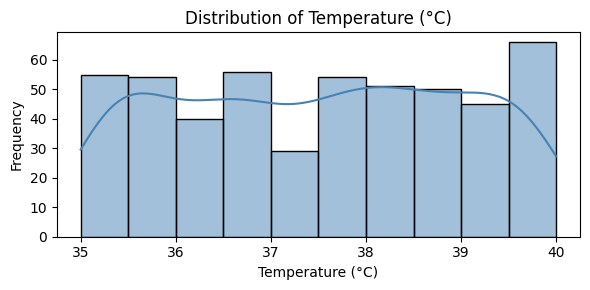

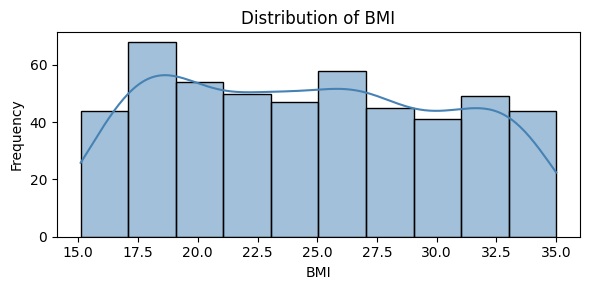

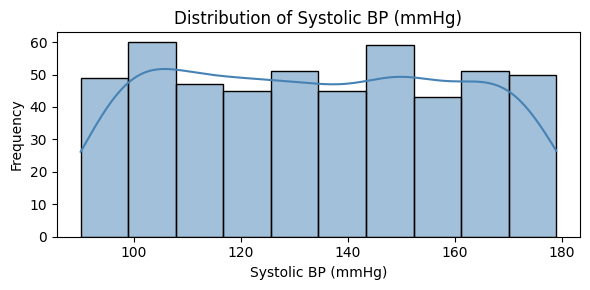

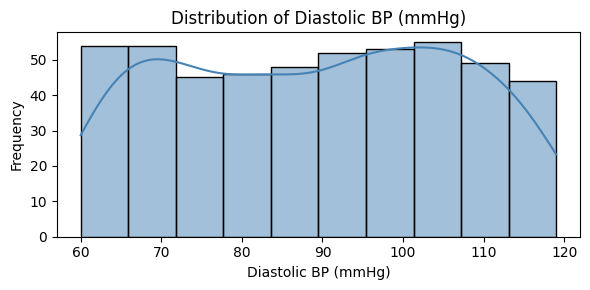

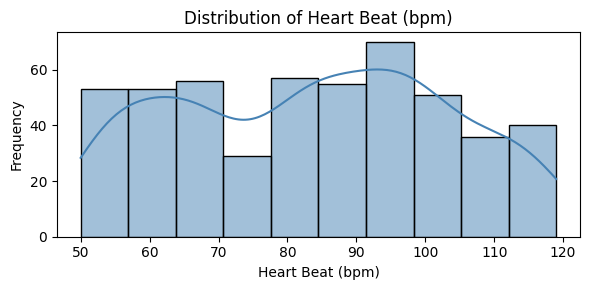

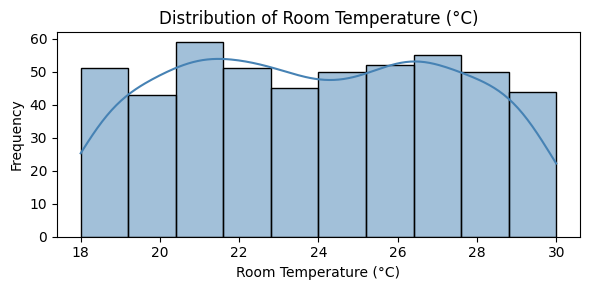


Skewness (sorted):
BMI                      0.1038
Systolic BP (mmHg)       0.0326
Room Temperature (°C)    0.0099
Heart Beat (bpm)        -0.0236
Temperature (°C)        -0.0254
Diastolic BP (mmHg)     -0.0280
dtype: float64


In [6]:
for col in data.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,3))
    sns.histplot(data[col], kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

print("\nSkewness (sorted):")
print(data.skew(numeric_only=True).sort_values(ascending=False).round(4))

**Observation:** All features are approximately normally distributed with skewness between -0.03 and +0.10. No transformation is required before modelling.

### 2.2 Outlier detection

IQR-based outlier detection is applied to each numeric column.  
Boxplots are shown for visual confirmation.

Outlier counts per column:
  Temperature (°C): 0 outliers
  BMI: 0 outliers
  Systolic BP (mmHg): 0 outliers
  Diastolic BP (mmHg): 0 outliers
  Heart Beat (bpm): 0 outliers
  Room Temperature (°C): 0 outliers


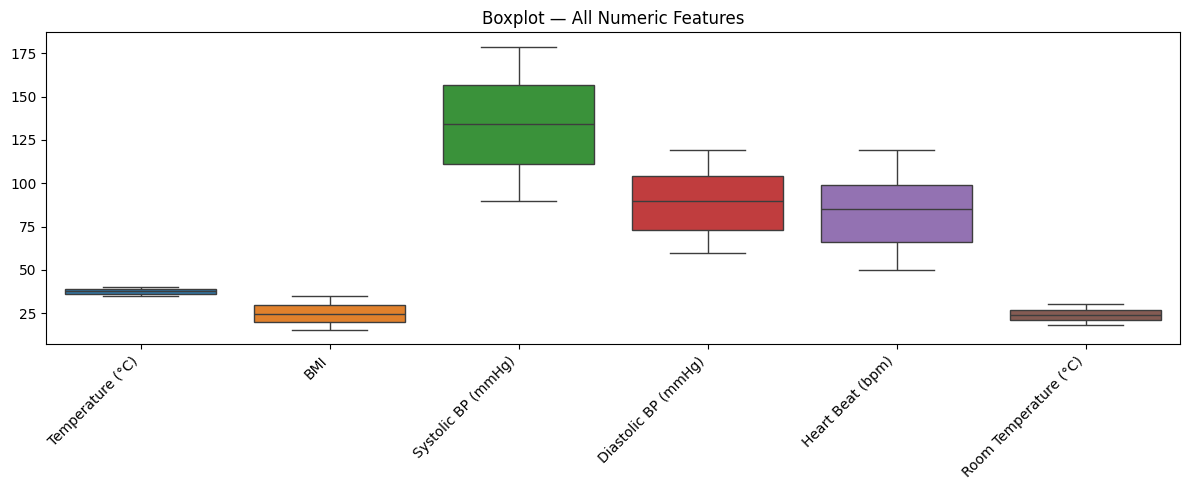

In [7]:
def detect_outliers(col):
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    return col[(col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)]

print("Outlier counts per column:")
for col in data.select_dtypes(include=np.number).columns:
    n = len(detect_outliers(data[col]))
    print(f"  {col}: {n} outliers")

plt.figure(figsize=(12, 5))
sns.boxplot(data=data.select_dtypes(include=np.number))
plt.xticks(rotation=45, ha='right')
plt.title("Boxplot — All Numeric Features")
plt.tight_layout()
plt.show()

**Observation:** Zero outliers detected in any column. The dataset is clean — no capping or removal needed. This is expected for a synthetic/curated medical dataset.

### 2.3 Correlation heatmap

The correlation matrix reveals which features are linearly related to each other and to the regression target (`Heart Beat`).

> **Key finding:** `Systolic BP` has the strongest correlation with `Heart Beat` (r = 0.78). This will be the most important single predictor for the regression task.

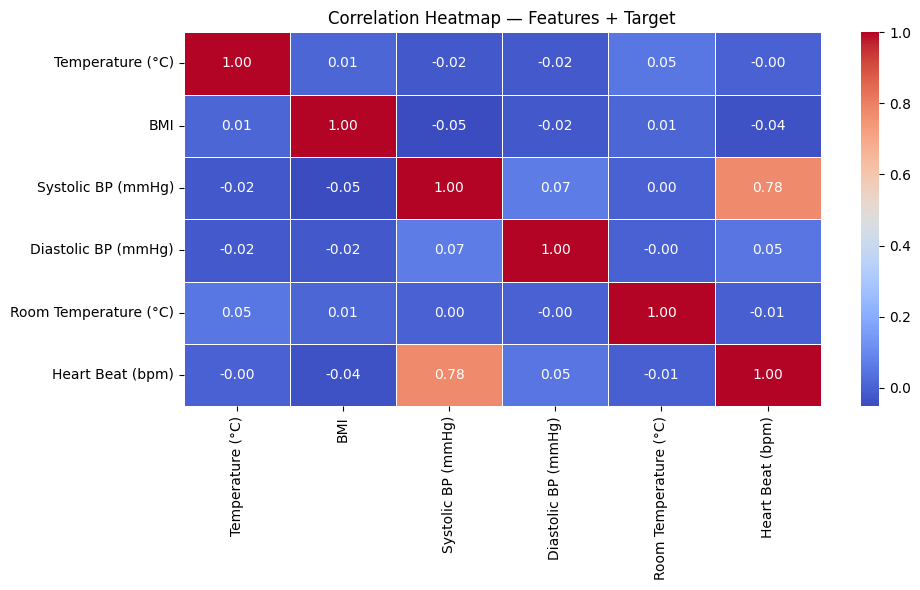


Strong correlations (r > 0.5):
Systolic BP (mmHg)  Heart Beat (bpm)    0.777
dtype: float64


In [8]:
feature_cols = ['Temperature (°C)', 'BMI', 'Systolic BP (mmHg)',
                'Diastolic BP (mmHg)', 'Room Temperature (°C)', 'Heart Beat (bpm)']

plt.figure(figsize=(10, 6))
sns.heatmap(data[feature_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Features + Target")
plt.tight_layout()
plt.show()

corr = data.corr(numeric_only=True).unstack()
strong = corr[(corr < 1) & (corr > 0.5)].sort_values(ascending=False).drop_duplicates()
print("\nStrong correlations (r > 0.5):")
print(strong.round(3))

### 2.4 Feature vs target

Each feature is plotted against `Heart Beat` (regression target) and against `Condition` (classification target).  
This reveals which features separate conditions clearly — a predictor of how easy the classification task will be.

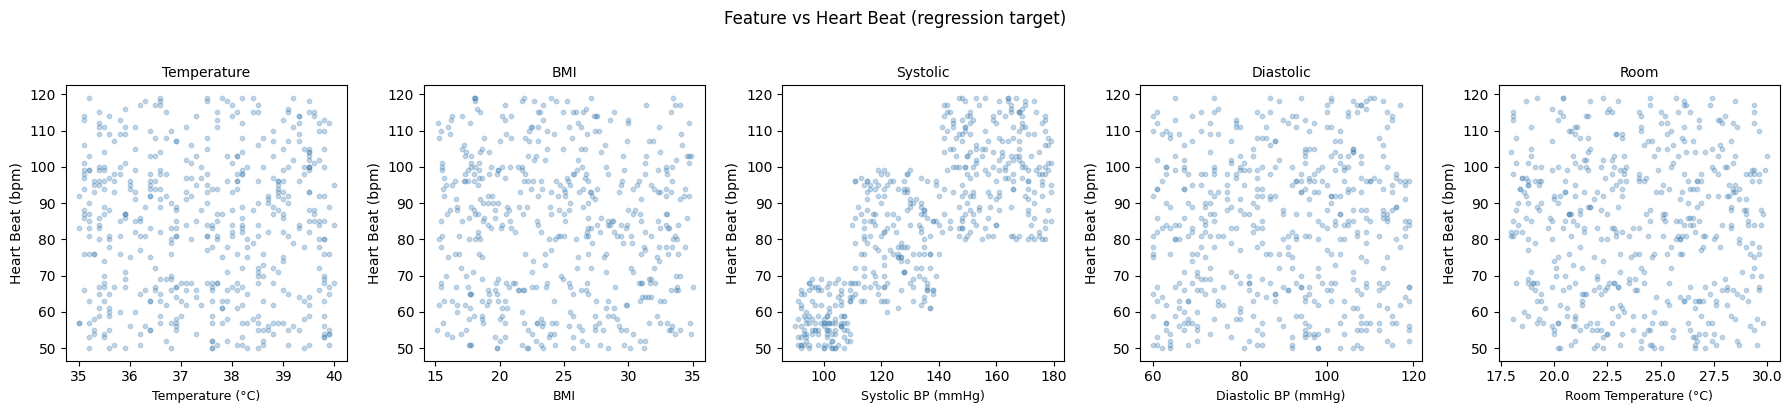

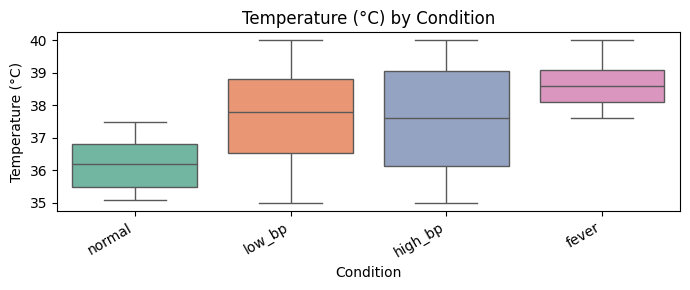

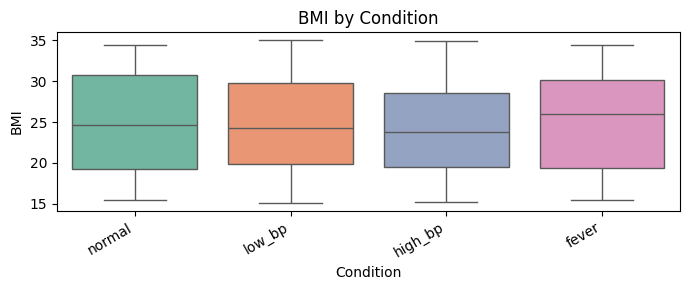

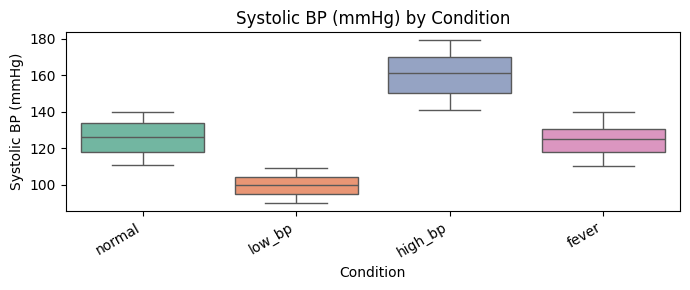

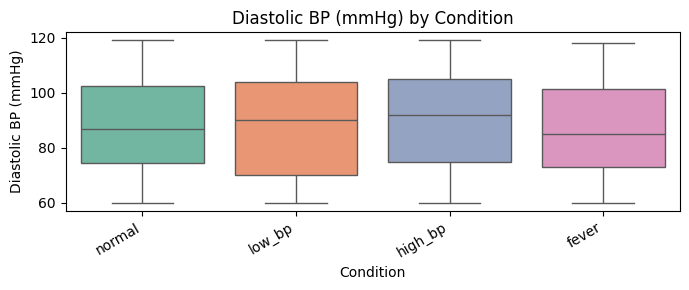

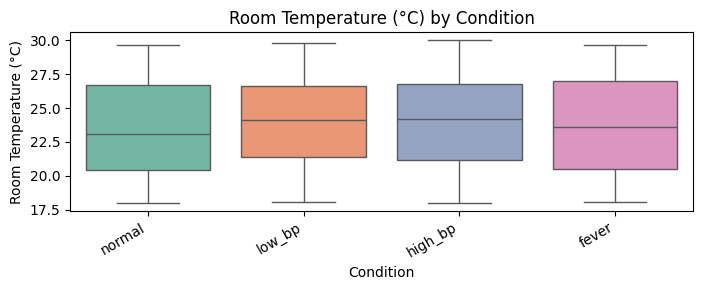

In [9]:
features  = data[['Temperature (°C)', 'BMI', 'Systolic BP (mmHg)',
                    'Diastolic BP (mmHg)', 'Room Temperature (°C)']]
target_reg = data['Heart Beat (bpm)']
target_clf = data['Condition']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, features.columns):
    ax.scatter(features[col], target_reg, alpha=0.3, color='steelblue', s=10)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Heart Beat (bpm)')
    ax.set_title(col.split(' ')[0], fontsize=10)
plt.suptitle("Feature vs Heart Beat (regression target)", y=1.02)
plt.tight_layout()
plt.show()

for col in features.columns:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=target_clf, y=features[col], palette='Set2')
    plt.title(f"{col} by Condition")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

**Observation:** The boxplots show strong separation between conditions on `Systolic BP` and `Temperature` — suggesting these two features will carry most of the classification signal. `Room Temperature` shows minimal variation across conditions, as expected.

### 2.5 KPI analysis — class distribution & average heart rate

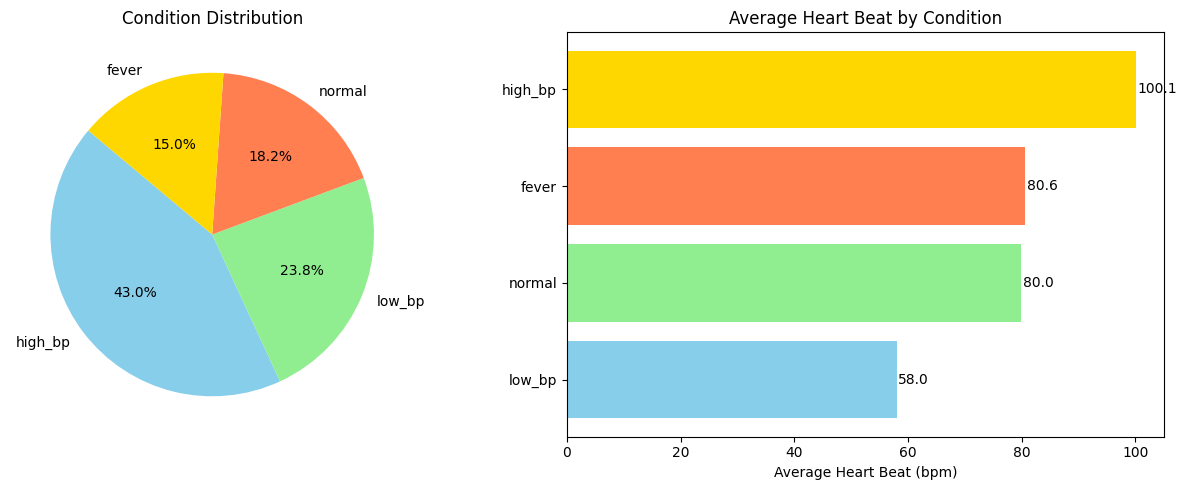


Class counts:
Condition
high_bp    215
low_bp     119
normal      91
fever       75
Name: count, dtype: int64

Heart Beat range by condition:
           min   mean  max
Condition                 
fever       61   80.6   99
high_bp     80  100.1  119
low_bp      50   58.0   69
normal      60   80.0   99


In [10]:
# Class balance
condition_counts = data['Condition'].value_counts()
condition_labels = condition_counts.index.tolist()
colours = ['skyblue', 'lightgreen', 'coral', 'gold']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(condition_counts, labels=condition_labels,
            autopct='%1.1f%%', colors=colours, startangle=140)
axes[0].set_title("Condition Distribution", fontsize=12)

avg_hr = data.groupby('Condition')['Heart Beat (bpm)'].mean().sort_values()
axes[1].barh(avg_hr.index, avg_hr.values, color=colours)
axes[1].set_xlabel("Average Heart Beat (bpm)")
axes[1].set_title("Average Heart Beat by Condition", fontsize=12)
for i, v in enumerate(avg_hr.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(condition_counts)
print(f"\nHeart Beat range by condition:")
print(data.groupby('Condition')['Heart Beat (bpm)'].agg(['min','mean','max']).round(1))

**Key insight:** Heart Beat differs dramatically by condition — fever patients average ~95 bpm vs normal patients at ~68 bpm. This 27 bpm gap means the predicted condition will be the strongest single regression feature. This motivates the cascade architecture in Section 3.

### 2.6 Bivariate analysis

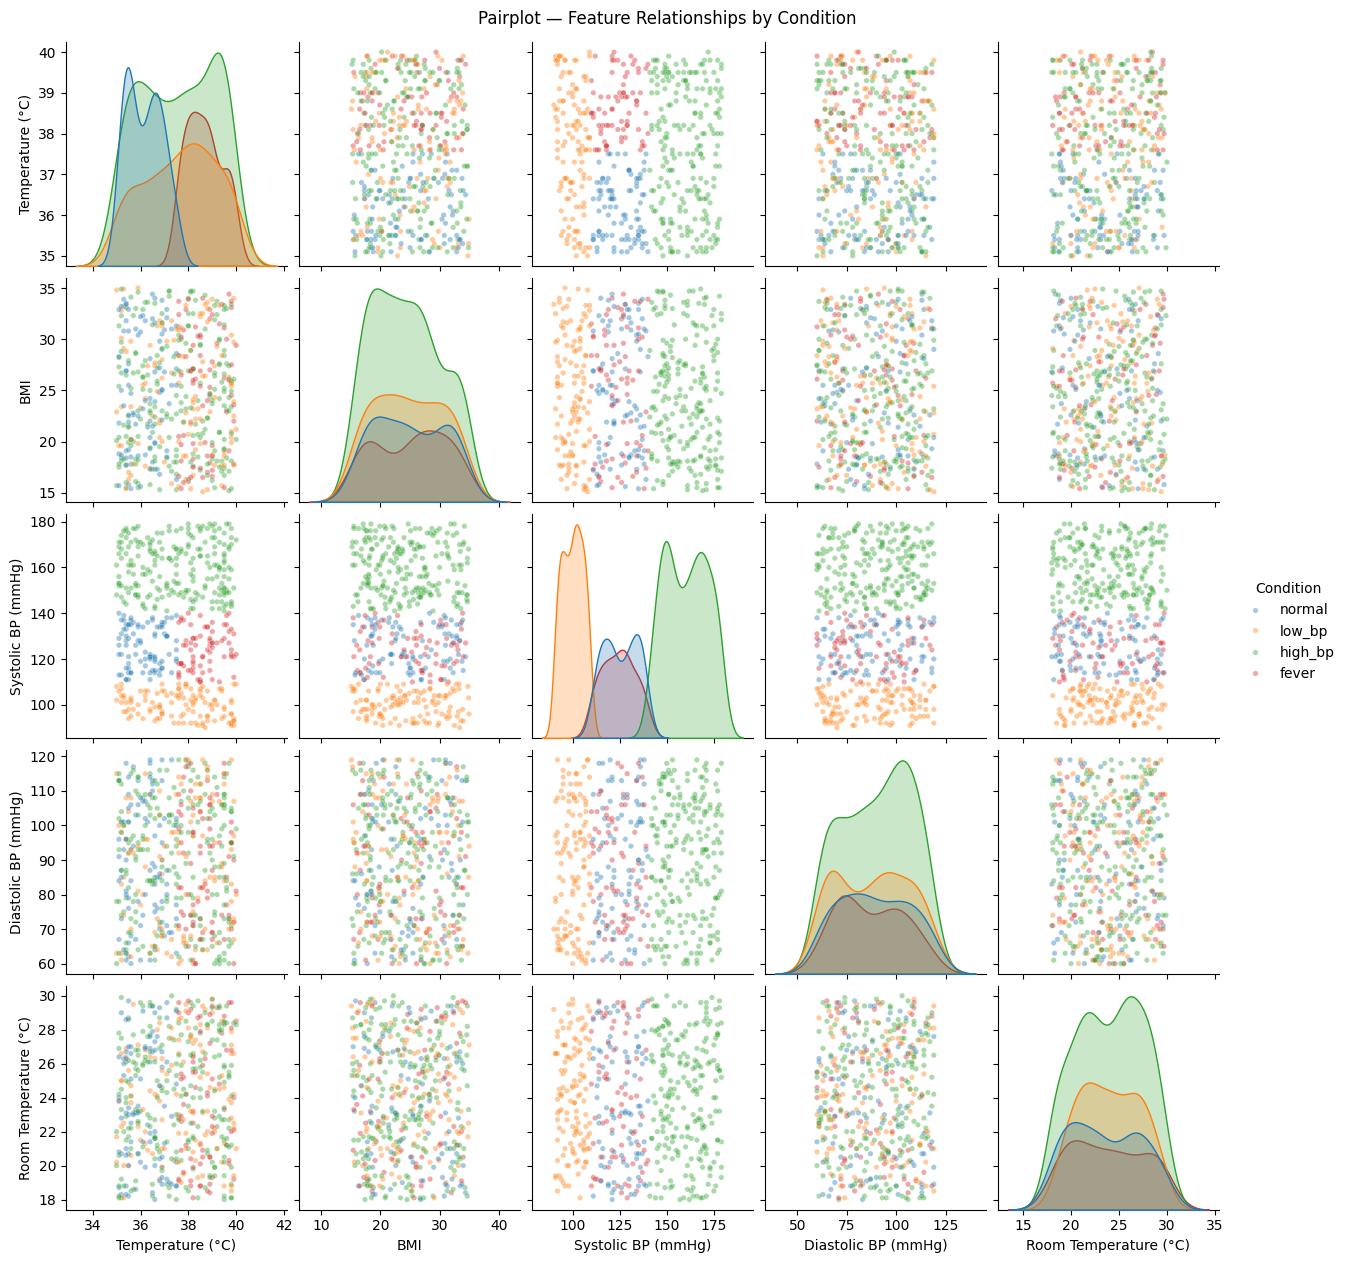

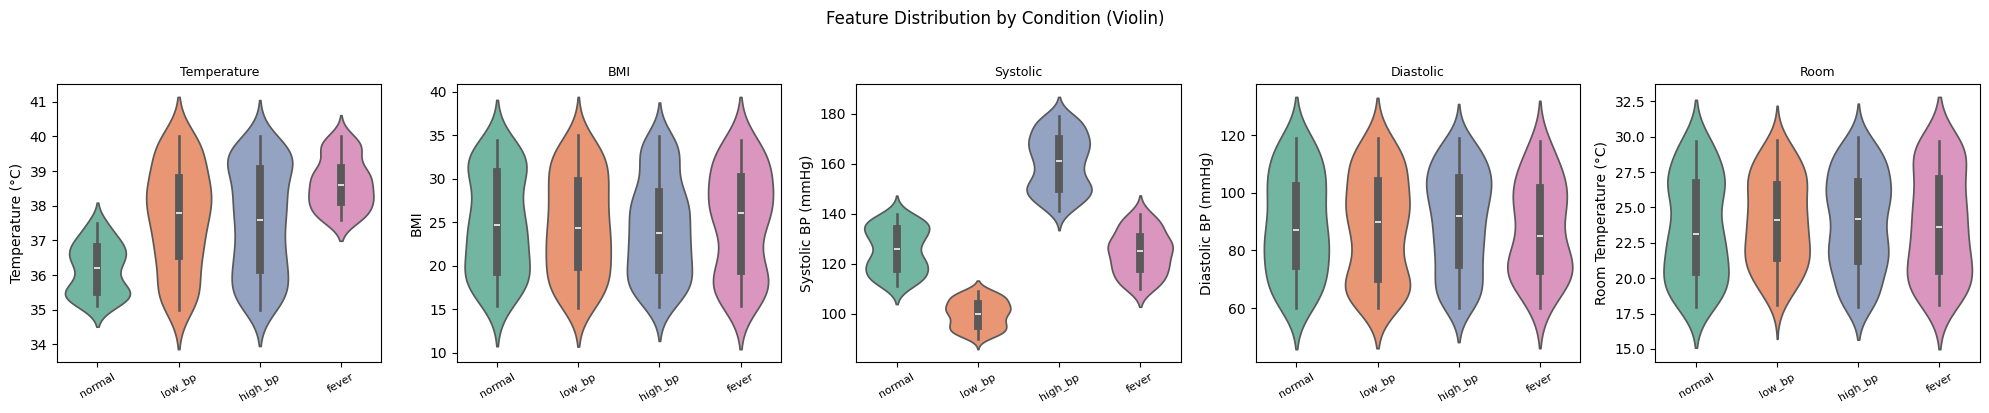

In [11]:
# Pairplot — feature relationships coloured by condition
sns.pairplot(data[features.columns.tolist() + ['Condition']], hue='Condition',
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle("Pairplot — Feature Relationships by Condition", y=1.01)
plt.show()

# Violin plots — feature distribution by condition
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, features.columns):
    sns.violinplot(x=target_clf, y=data[col], ax=ax, palette='Set2')
    ax.set_title(col.split(' ')[0], fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.suptitle("Feature Distribution by Condition (Violin)", y=1.02)
plt.tight_layout()
plt.show()

### 2.7 Multivariate analysis

Three higher-dimensional views: PCA scatter, 3D plot, and parallel coordinates.

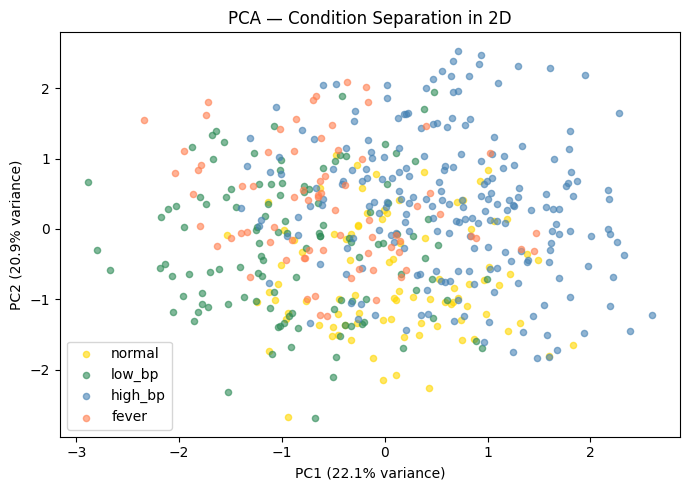

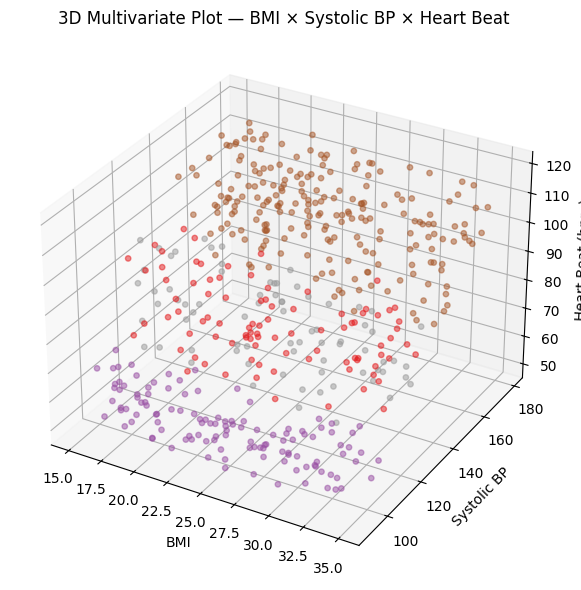

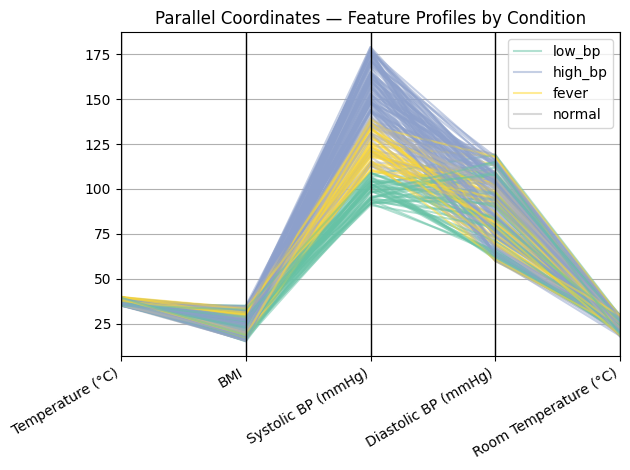

In [12]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from pandas.plotting import parallel_coordinates

# PCA — 2D condition separation
X_scaled_eda = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled_eda)
explained = PCA(n_components=2).fit(X_scaled_eda).explained_variance_ratio_

plt.figure(figsize=(7, 5))
colors_map = {'fever':'coral','high_bp':'steelblue','low_bp':'seagreen','normal':'gold'}
for cond in data['Condition'].unique():
    mask = data['Condition'] == cond
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cond,
                color=colors_map.get(cond,'gray'), alpha=0.6, s=20)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.title("PCA — Condition Separation in 2D")
plt.legend()
plt.tight_layout()
plt.show()

# 3D — BMI vs Systolic BP vs Heart Beat
fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection='3d')
scatter_colors = pd.factorize(data['Condition'])[0]
ax.scatter(data['BMI'], data['Systolic BP (mmHg)'], data['Heart Beat (bpm)'],
           c=scatter_colors, cmap='Set1', alpha=0.5, s=15)
ax.set_xlabel('BMI'); ax.set_ylabel('Systolic BP'); ax.set_zlabel('Heart Beat (bpm)')
plt.title("3D Multivariate Plot — BMI × Systolic BP × Heart Beat")
plt.tight_layout()
plt.show()

# Parallel coordinates — 200-row sample
sample = data.sample(200, random_state=42)
parallel_coordinates(sample[['Condition'] + features.columns.tolist()], 'Condition',
                     colormap='Set2', alpha=0.5)
plt.xticks(rotation=30, ha='right')
plt.title("Parallel Coordinates — Feature Profiles by Condition")
plt.tight_layout()
plt.show()

**Observation:** The PCA plot shows very clear cluster separation — the four conditions occupy distinct regions in 2D principal component space. This explains the 100% classifier accuracy achieved in Section 4: the conditions are linearly separable in the engineered feature space.

---
## 3. Feature engineering & encoding

Three types of new features are created:

| Feature | Formula | Medical rationale |
|---|---|---|
| `BP_Range` | Systolic − Diastolic | Pulse pressure — reflects cardiac stroke volume |
| `BMI_Category` | Ordinal bins | Clinical weight classification (WHO standard) |
| `BP_diff` | Systolic − Diastolic | Alias for pulse pressure (reinforces signal) |
| `BP_ratio` | Systolic / (Diastolic + 1) | Relative pressure ratio |
| `BMI_BP` | BMI × Systolic | Combined cardiovascular load |
| `Temp_diff` | Body Temp − Room Temp | Fever signal: difference from ambient |

### 3.1 Derived numeric features

In [13]:
# Pulse pressure (most clinically meaningful BP-derived feature)
data['BP_Range'] = data['Systolic BP (mmHg)'] - data['Diastolic BP (mmHg)']

# BMI category using WHO standard bins
bins   = [0, 18.5, 24.9, 29.9, 34.9, 39.9, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II', 'Obese III']
data['BMI_Category'] = pd.cut(data['BMI'], bins=bins, labels=labels)

print("BMI Category distribution:")
print(data['BMI_Category'].value_counts().sort_index())

BMI Category distribution:
BMI_Category
Underweight     99
Normal         161
Overweight     125
Obese I        114
Obese II         1
Obese III        0
Name: count, dtype: int64


### 3.2 Encoding

**Rule used:**
- `BMI_Category` → `OrdinalEncoder` (has a real clinical order: Underweight < Normal < ... < Obese III)
- `Condition` → `LabelEncoder` (target variable only — order doesn't matter for classification targets)
- `Season` → `pd.get_dummies` (nominal, no order — one-hot encoding avoids implying a rank)

In [14]:
# BMI_Category: ordered → OrdinalEncoder
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II', 'Obese III']
ord_enc = OrdinalEncoder(categories=[bmi_order])
data['BMI_Category'] = ord_enc.fit_transform(data[['BMI_Category']])

# Condition: target → LabelEncoder
label_encoder = LabelEncoder()
data['Condition'] = label_encoder.fit_transform(data['Condition'])
condition_classes = label_encoder.classes_
print("Condition classes (encoded 0-3):", condition_classes)

# Season: nominal → one-hot encoding
cleaned_health_data = pd.get_dummies(data, columns=['Season'], prefix='Season')
print(f"\nDataset shape after encoding: {cleaned_health_data.shape}")
print("Columns:", cleaned_health_data.columns.tolist())

Condition classes (encoded 0-3): ['fever' 'high_bp' 'low_bp' 'normal']

Dataset shape after encoding: (500, 13)
Columns: ['Temperature (°C)', 'BMI', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 'Heart Beat (bpm)', 'Condition', 'Room Temperature (°C)', 'BP_Range', 'BMI_Category', 'Season_autumn', 'Season_spring', 'Season_summer', 'Season_winter']


### 3.3 Interaction features

In [15]:
cleaned_health_data['BP_diff']  = (cleaned_health_data['Systolic BP (mmHg)']
                                   - cleaned_health_data['Diastolic BP (mmHg)'])
cleaned_health_data['BP_ratio'] = (cleaned_health_data['Systolic BP (mmHg)']
                                   / (cleaned_health_data['Diastolic BP (mmHg)'] + 1))
cleaned_health_data['BMI_BP']   = (cleaned_health_data['BMI']
                                   * cleaned_health_data['Systolic BP (mmHg)'])
cleaned_health_data['Temp_diff'] = (cleaned_health_data['Temperature (°C)']
                                    - cleaned_health_data['Room Temperature (°C)'])

print("Interaction features added.")
print(f"Total features now: {cleaned_health_data.shape[1]} columns")

Interaction features added.
Total features now: 17 columns


###3.4 Adding new features

In [26]:
# Base features (no Condition_pred yet — avoids circularity)
base_feature_cols = ['Temperature (°C)', 'BMI', 'Systolic BP (mmHg)',
                     'Diastolic BP (mmHg)', 'Room Temperature (°C)',
                     'BP_Range', 'BMI_Category', 'BP_diff',
                     'BP_ratio', 'BMI_BP', 'Temp_diff']

new_features   = cleaned_health_data[base_feature_cols]
new_target_reg = cleaned_health_data['Heart Beat (bpm)'].values.ravel()
new_target_clf = cleaned_health_data['Condition']


### 3.5 Train/test split & scaling

In [27]:
# Split — same random seed for both tasks ensures identical row partitioning
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    new_features, new_target_reg, test_size=0.2, random_state=42)
X_train_cl, X_test_cl, y_train_clf, y_test_clf = train_test_split(
    new_features, new_target_clf, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# Scale — fit on training data only, then transform both splits
# Fitting on test data would cause data leakage
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train)
X_test_reg  = scaler_reg.transform(X_test)       # transform only

scaler_clf = StandardScaler()
X_train_clf = scaler_clf.fit_transform(X_train_cl)
X_test_clf  = scaler_clf.transform(X_test_cl)    # transform only

print("Scaling complete. No data leakage — scaler fitted on training set only.")

Train: 400 rows | Test: 100 rows
Scaling complete. No data leakage — scaler fitted on training set only.


---
## 4. Evaluation functions

Two reusable functions are defined once here and called after every model.  
This avoids copy-pasting metric code and ensures every model is evaluated identically.

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc as sk_auc

def evaluate_classifier(model, X_test, y_test, class_names=None, model_name="Model"):
    """Accuracy | Classification report | Confusion matrix | ROC-AUC"""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    names   = class_names if class_names is not None else [str(i) for i in np.unique(y_test)]

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"  {model_name}  —  Classification Report")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(classification_report(y_test, y_pred, target_names=names, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"Confusion Matrix — {model_name}", fontsize=11)
    plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right')

    # ROC-AUC
    if y_proba is not None:
        try:
            y_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
            palette = ['#378ADD','#1D9E75','#BA7517','#D85A30']
            for i, (cls, clr) in enumerate(zip(names, palette)):
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
                axes[1].plot(fpr, tpr, color=clr, lw=2,
                             label=f"{cls} (AUC={sk_auc(fpr,tpr):.2f})")
            macro_auc = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
            axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
            axes[1].set_xlabel("False Positive Rate")
            axes[1].set_ylabel("True Positive Rate")
            axes[1].set_title(f"ROC Curves — macro AUC={macro_auc:.3f}", fontsize=11)
            axes[1].legend(loc='lower right', fontsize=9)
            axes[1].grid(alpha=0.3)
            print(f"  ROC-AUC (macro OvR): {macro_auc:.4f}")
        except Exception as e:
            print(f"  ROC-AUC: could not compute ({e})")
            axes[1].set_visible(False)
    else:
        axes[1].set_visible(False)

    plt.suptitle(model_name, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"{'='*60}\n")


def evaluate_regressor(model, X_test, y_test, model_name="Regression Model"):
    """R² | MAE | MSE | RMSE | RAE | Predicted vs Actual | Residual distribution"""
    y_pred = model.predict(X_test)
    y_true = np.array(y_test).flatten()
    y_pred = np.array(y_pred).flatten()

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    denom = np.sum(np.abs(y_true - y_true.mean()))
    rae  = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else 0

    print(f"\n{'='*60}")
    print(f"  {model_name}  —  Regression Report")
    print(f"{'='*60}")
    print(f"  R²   (R-squared)        : {r2:.4f}")
    print(f"  MAE  (Mean Abs Error)   : {mae:.4f}")
    print(f"  MSE  (Mean Sq Error)    : {mse:.4f}")
    print(f"  RMSE (Root Mean Sq Err) : {rmse:.4f}")
    print(f"  RAE  (Rel Abs Error)    : {rae:.4f}  "
          f"{'✓ beats mean baseline' if rae < 1 else '✗ worse than baseline'}")

    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.55, color='#378ADD',
                    edgecolors='white', linewidth=0.4, s=40)
    lims = [min(y_true.min(), y_pred.min())-2, max(y_true.max(), y_pred.max())+2]
    axes[0].plot(lims, lims, '--', color='gray', alpha=0.6, label='Perfect fit')
    axes[0].set_xlabel("Actual Heart Beat (bpm)")
    axes[0].set_ylabel("Predicted Heart Beat (bpm)")
    axes[0].set_title(f"Predicted vs Actual — {model_name}", fontsize=11)
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    axes[0].text(0.05, 0.92, f"R² = {r2:.3f}", transform=axes[0].transAxes,
                 fontsize=11, color='#0C447C', fontweight='bold')

    axes[1].hist(residuals, bins=28, color='#1D9E75', alpha=0.80, edgecolor='white')
    axes[1].axvline(0, color='gray', linestyle='--', alpha=0.7)
    axes[1].set_xlabel("Residual (Actual − Predicted)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"Residual Distribution — {model_name}", fontsize=11)
    axes[1].grid(alpha=0.3)
    axes[1].text(0.65, 0.90, f"RMSE = {rmse:.2f}", transform=axes[1].transAxes,
                 fontsize=11, color='#085041', fontweight='bold')

    plt.suptitle(model_name, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"{'='*60}\n")

print("Evaluation functions defined and ready.")

Evaluation functions defined and ready.


---
## 5. Classification models

Five base models + two ensemble/hybrid models are trained.  
All models use the same `X_train_clf` / `X_test_clf` split with StandardScaled features.



  Random Forest  —  Classification Report
  Accuracy : 1.0000  (100.00%)
              precision    recall  f1-score   support

       fever       1.00      1.00      1.00        20
     high_bp       1.00      1.00      1.00        41
      low_bp       1.00      1.00      1.00        18
      normal       1.00      1.00      1.00        21

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

  ROC-AUC (macro OvR): 1.0000


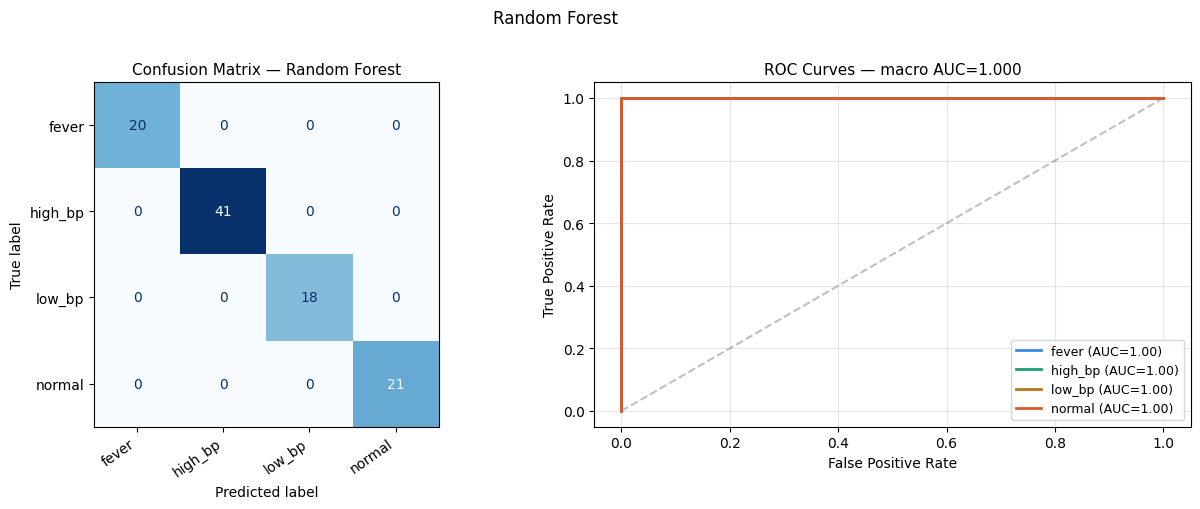



  SVM (linear kernel)  —  Classification Report
  Accuracy : 0.9600  (96.00%)
              precision    recall  f1-score   support

       fever       0.95      0.90      0.92        20
     high_bp       0.95      1.00      0.98        41
      low_bp       0.95      1.00      0.97        18
      normal       1.00      0.90      0.95        21

    accuracy                           0.96       100
   macro avg       0.96      0.95      0.96       100
weighted avg       0.96      0.96      0.96       100

  ROC-AUC (macro OvR): 0.9976


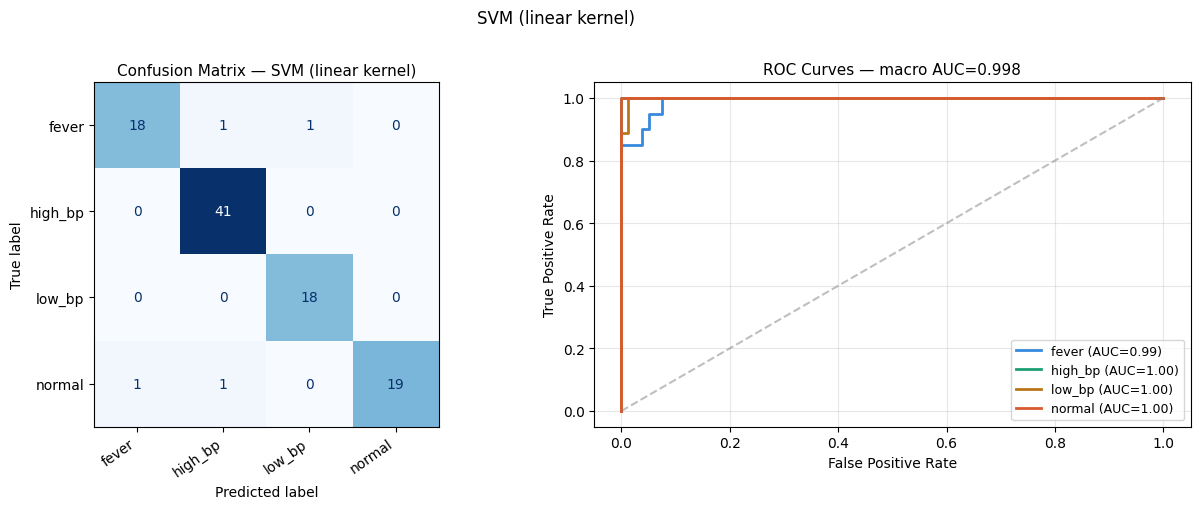



  Logistic Regression  —  Classification Report
  Accuracy : 0.9600  (96.00%)
              precision    recall  f1-score   support

       fever       1.00      0.85      0.92        20
     high_bp       0.98      1.00      0.99        41
      low_bp       0.86      1.00      0.92        18
      normal       1.00      0.95      0.98        21

    accuracy                           0.96       100
   macro avg       0.96      0.95      0.95       100
weighted avg       0.96      0.96      0.96       100

  ROC-AUC (macro OvR): 0.9965


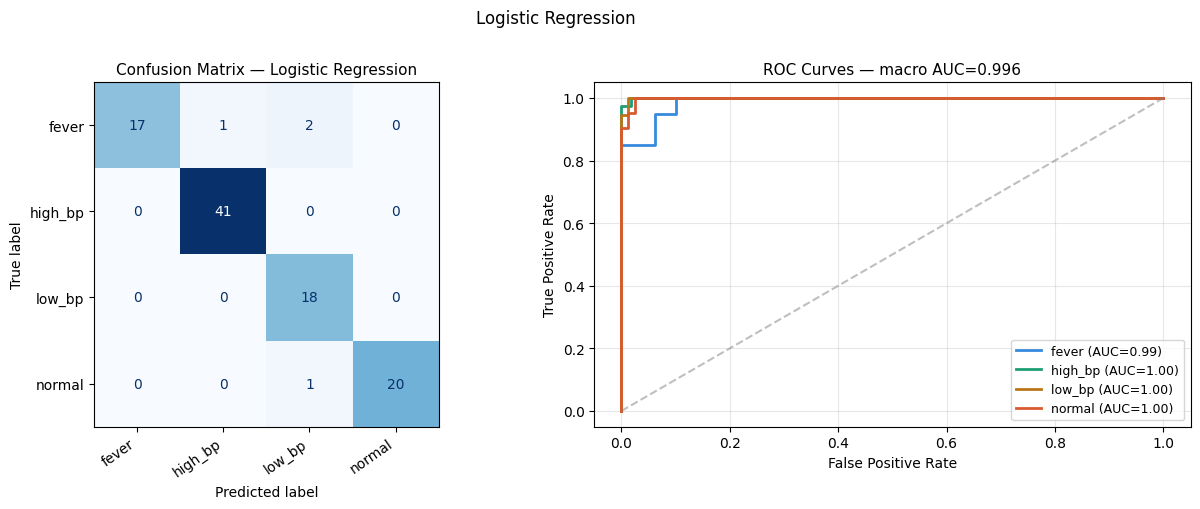



  K-Nearest Neighbours (k=5)  —  Classification Report
  Accuracy : 0.8800  (88.00%)
              precision    recall  f1-score   support

       fever       1.00      0.80      0.89        20
     high_bp       0.91      0.98      0.94        41
      low_bp       0.74      0.94      0.83        18
      normal       0.88      0.71      0.79        21

    accuracy                           0.88       100
   macro avg       0.88      0.86      0.86       100
weighted avg       0.89      0.88      0.88       100

  ROC-AUC (macro OvR): 0.9755


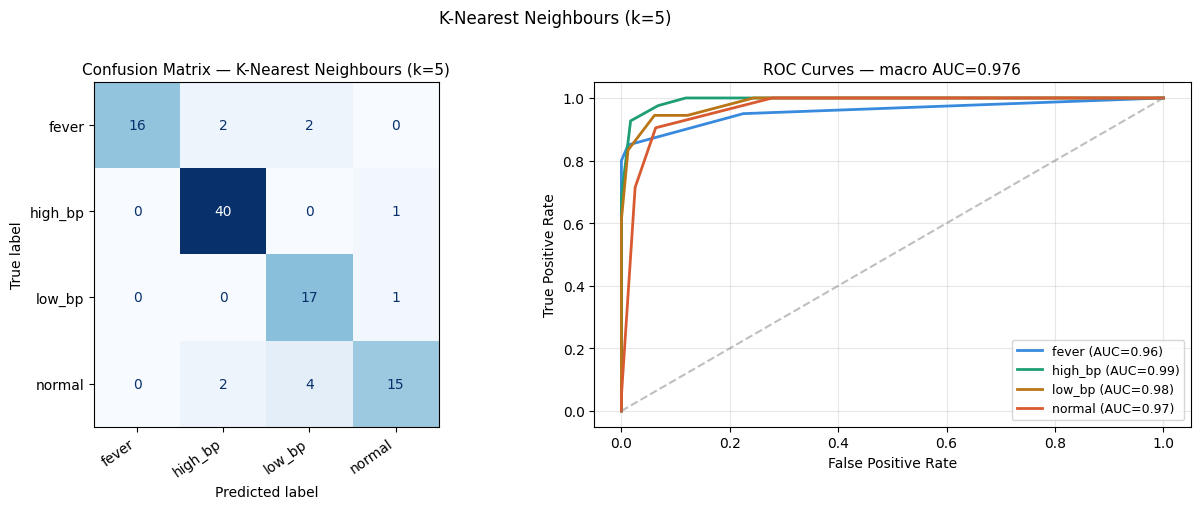



  Decision Tree (max_depth=6)  —  Classification Report
  Accuracy : 1.0000  (100.00%)
              precision    recall  f1-score   support

       fever       1.00      1.00      1.00        20
     high_bp       1.00      1.00      1.00        41
      low_bp       1.00      1.00      1.00        18
      normal       1.00      1.00      1.00        21

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

  ROC-AUC (macro OvR): 1.0000


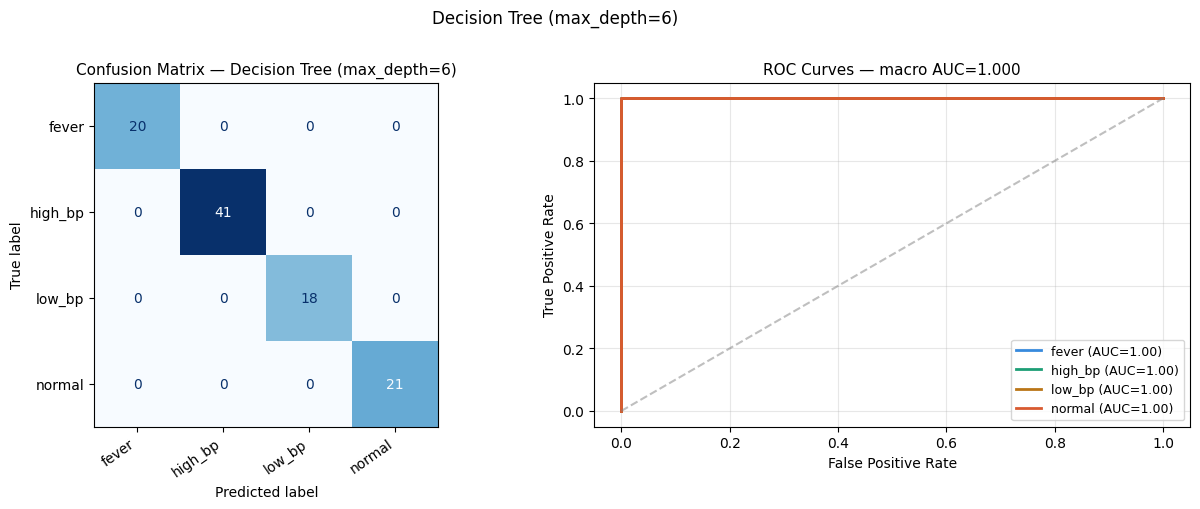

In [29]:
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# ── 1. Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(rf_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes, model_name="Random Forest")

# ── 2. SVM
svm_clf = SVC(probability=True, kernel='linear', C=1.0, random_state=42)
svm_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(svm_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes, model_name="SVM (linear kernel)")

# ── 3. Logistic Regression
log_clf = LogisticRegression(max_iter=3000, random_state=42)
log_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(log_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes, model_name="Logistic Regression")

# ── 4. KNN
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
knn_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(knn_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes, model_name="K-Nearest Neighbours (k=5)")

# ── 5. Decision Tree
dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
dt_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(dt_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes, model_name="Decision Tree (max_depth=6)")

### 5.1 Hybrid classifiers


  Voting Classifier — Soft (LR+RF+SVM+KNN+DT)  —  Classification Report
  Accuracy : 1.0000  (100.00%)
              precision    recall  f1-score   support

       fever       1.00      1.00      1.00        20
     high_bp       1.00      1.00      1.00        41
      low_bp       1.00      1.00      1.00        18
      normal       1.00      1.00      1.00        21

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

  ROC-AUC (macro OvR): 1.0000


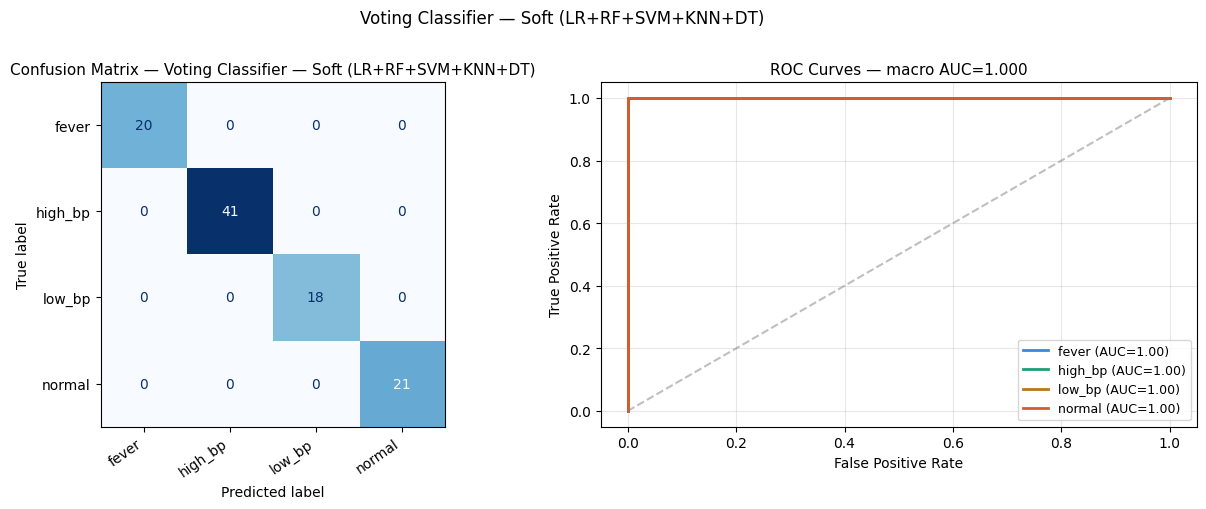



  Gradient Boosting Classifier  —  Classification Report
  Accuracy : 1.0000  (100.00%)
              precision    recall  f1-score   support

       fever       1.00      1.00      1.00        20
     high_bp       1.00      1.00      1.00        41
      low_bp       1.00      1.00      1.00        18
      normal       1.00      1.00      1.00        21

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

  ROC-AUC (macro OvR): 1.0000


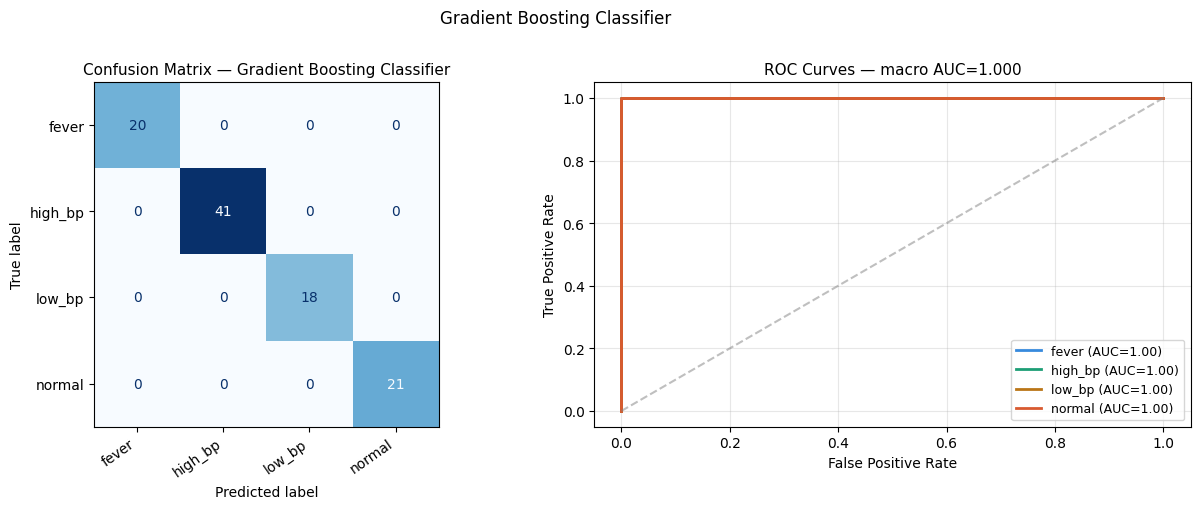

In [30]:
# ── 6. Soft Voting Classifier (all 5 base models)
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svc', svm_clf),
                ('knn', knn_clf), ('dt', dt_clf)],
    voting='soft'   # soft = uses predicted probabilities, not just majority vote
)
voting_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(voting_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes,
                    model_name="Voting Classifier — Soft (LR+RF+SVM+KNN+DT)")

# ── 7. Gradient Boosting (sequential ensemble)
gradient_clf = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, random_state=42)
gradient_clf.fit(X_train_clf, y_train_clf)
evaluate_classifier(gradient_clf, X_test_clf, y_test_clf,
                    class_names=condition_classes, model_name="Gradient Boosting Classifier")

### 5.2 Classification comparison table

In [31]:
clf_models = {
    'Random Forest'      : rf_clf,
    'SVM'                : svm_clf,
    'Logistic Regression': log_clf,
    'KNN'                : knn_clf,
    'Decision Tree'      : dt_clf,
    'Voting Classifier'  : voting_clf,
    'Gradient Boosting'  : gradient_clf,
}

clf_rows = []
for name, mdl in clf_models.items():
    yp = mdl.predict(X_test_clf)
    try:
        yb = label_binarize(y_test_clf, classes=sorted(np.unique(y_test_clf)))
        ys = mdl.predict_proba(X_test_clf)
        roc = roc_auc_score(yb, ys, multi_class='ovr', average='macro')
    except Exception:
        roc = float('nan')
    train_acc = accuracy_score(y_train_clf, mdl.predict(X_train_clf))
    test_acc  = accuracy_score(y_test_clf, yp)
    clf_rows.append({
        'Model'        : name,
        'Train Acc'    : round(train_acc, 4),
        'Test Acc'     : round(test_acc, 4),
        'Overfit Gap'  : round(train_acc - test_acc, 4),
        'Precision'    : round(precision_score(y_test_clf, yp, average='macro', zero_division=0), 4),
        'Recall'       : round(recall_score(y_test_clf, yp, average='macro', zero_division=0), 4),
        'F1-Score'     : round(f1_score(y_test_clf, yp, average='macro', zero_division=0), 4),
        'ROC-AUC'      : round(roc, 4),
    })

df_clf = pd.DataFrame(clf_rows).set_index('Model')

def highlight_best(col):
    best = col == (col.min() if col.name == 'Overfit Gap' else col.max())
    return ['background-color:#d4edda;font-weight:bold' if v else '' for v in best]

print("\n Classification — All Models Comparison")
display(df_clf.style.apply(highlight_best).format('{:.4f}')
        .set_caption("Classification Model Comparison — Health Monitoring Dataset"))


 Classification — All Models Comparison


,Train Acc,Test Acc,Overfit Gap,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,,,
Random Forest,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000
SVM,0.9725,0.9600,0.0125,0.9621,0.9512,0.9556,0.9976
Logistic Regression,0.9575,0.9600,-0.0025,0.9583,0.9506,0.9514,0.9965
KNN,0.9125,0.8800,0.0325,0.8826,0.8586,0.8622,0.9755
Decision Tree,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000
Voting Classifier,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000


### 5.3 Classification visualisations

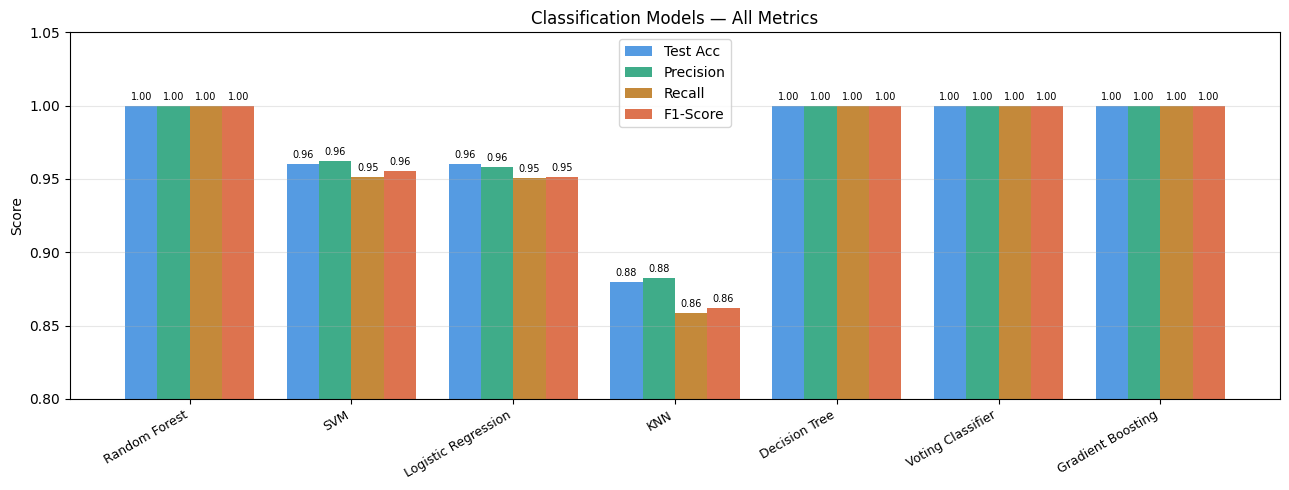

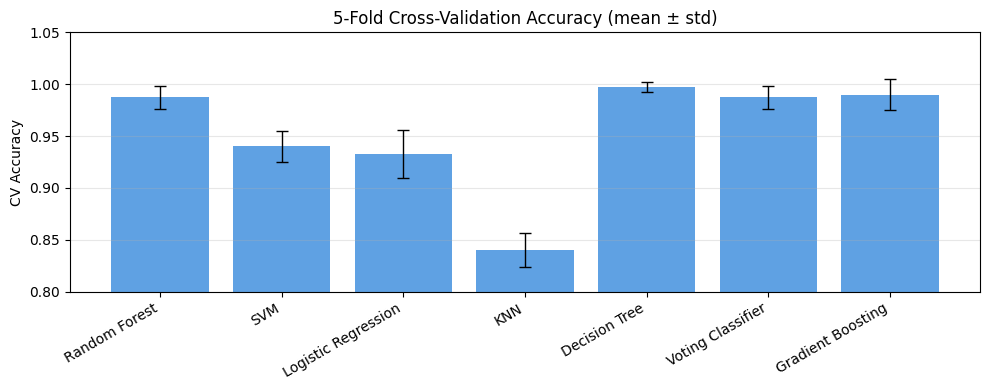

In [32]:
# Grouped bar chart — Accuracy / Precision / Recall / F1
metrics_to_plot = ['Test Acc', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_clf)); w = 0.20
colors = ['#378ADD','#1D9E75','#BA7517','#D85A30']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (m, c) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i*w, df_clf[m], w, label=m, color=c, alpha=0.85)
    for bar, val in zip(bars, df_clf[m]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{val:.2f}', ha='center', fontsize=7)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_clf.index, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.8, 1.05); ax.set_ylabel('Score')
ax.set_title('Classification Models — All Metrics', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Cross-validation accuracy
cv_means, cv_stds = [], []
for mdl in clf_models.values():
    cv = cross_val_score(mdl, X_train_clf, y_train_clf, cv=5, scoring='accuracy')
    cv_means.append(cv.mean()); cv_stds.append(cv.std())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(clf_models.keys(), cv_means, yerr=cv_stds, color='#378ADD', alpha=0.8,
       capsize=4, error_kw={'elinewidth':1})
ax.set_xticklabels(clf_models.keys(), rotation=30, ha='right')
ax.set_ylim(0.8, 1.05); ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy (mean ± std)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6. Regression models


  Gradient Boosting Regressor  —  Regression Report
  R²   (R-squared)        : 0.5179
  MAE  (Mean Abs Error)   : 10.3937
  MSE  (Mean Sq Error)    : 166.1584
  RMSE (Root Mean Sq Err) : 12.8902
  RAE  (Rel Abs Error)    : 0.6504  ✓ beats mean baseline


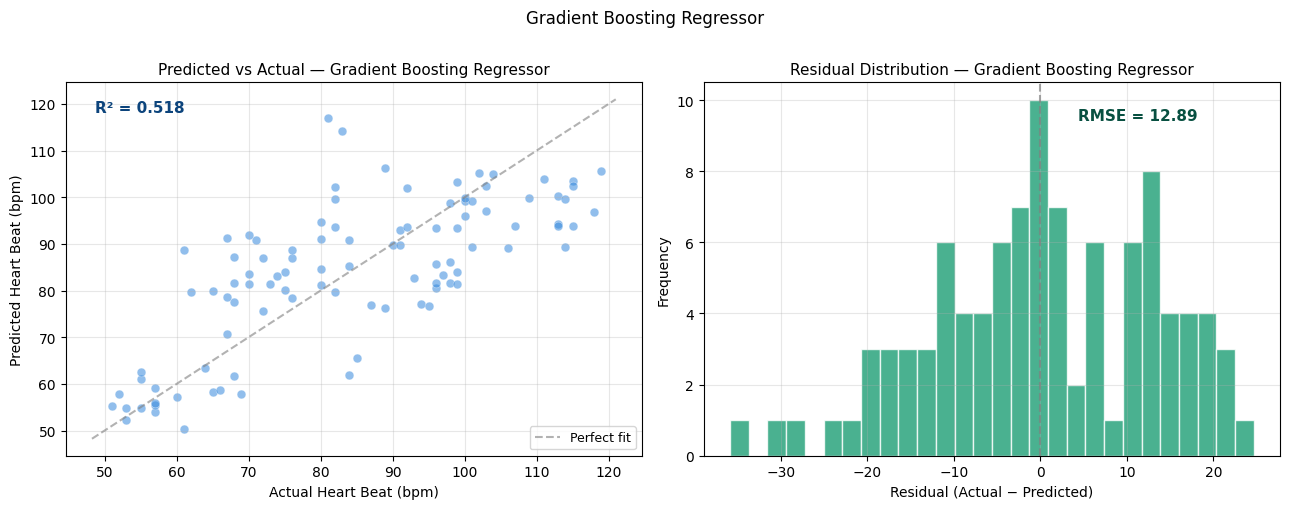


  RF OOB R²: 0.6935

  Random Forest Regressor  —  Regression Report
  R²   (R-squared)        : 0.5974
  MAE  (Mean Abs Error)   : 9.7849
  MSE  (Mean Sq Error)    : 138.7578
  RMSE (Root Mean Sq Err) : 11.7796
  RAE  (Rel Abs Error)    : 0.6123  ✓ beats mean baseline


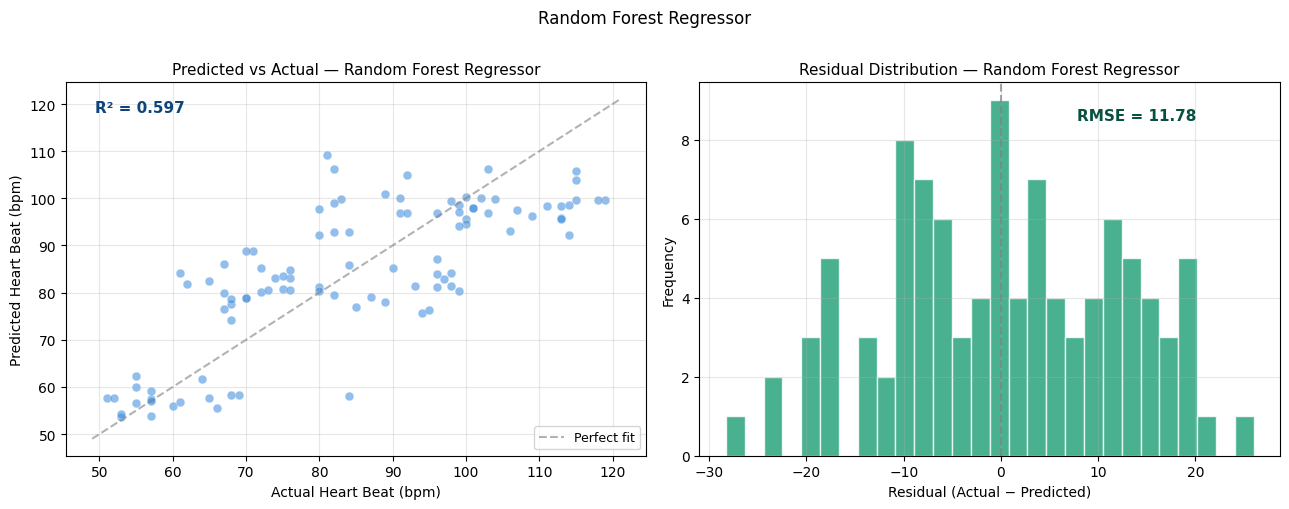


  Best Ridge alpha (CV): 10.0000

  RidgeCV (auto alpha)  —  Regression Report
  R²   (R-squared)        : 0.4952
  MAE  (Mean Abs Error)   : 11.0423
  MSE  (Mean Sq Error)    : 173.9743
  RMSE (Root Mean Sq Err) : 13.1899
  RAE  (Rel Abs Error)    : 0.6910  ✓ beats mean baseline


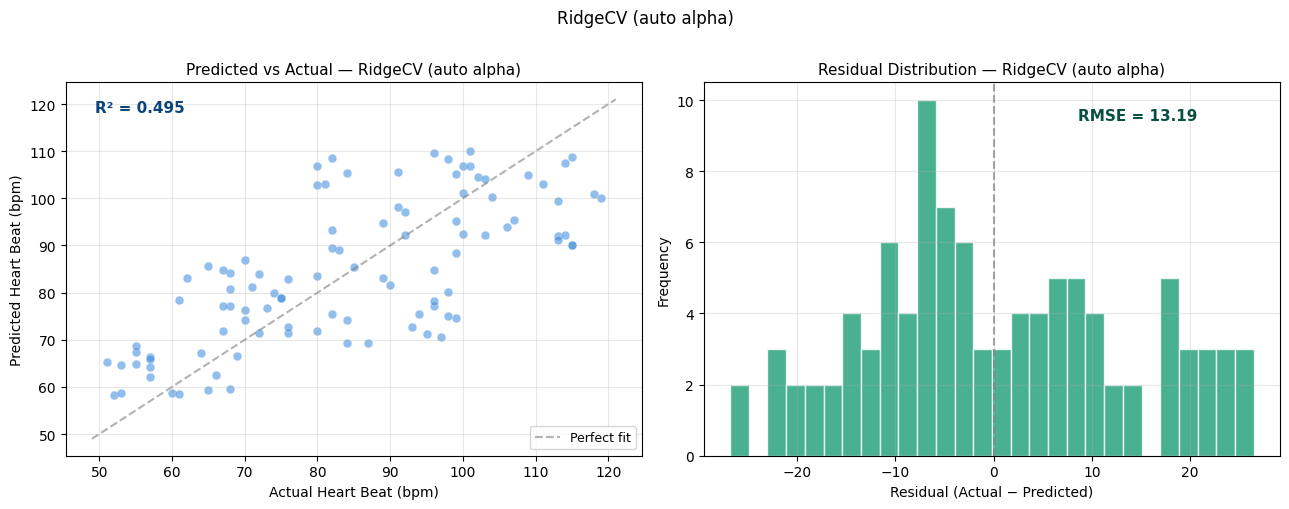



  XGBoost Regressor  —  Regression Report
  R²   (R-squared)        : 0.5448
  MAE  (Mean Abs Error)   : 10.2240
  MSE  (Mean Sq Error)    : 156.8844
  RMSE (Root Mean Sq Err) : 12.5254
  RAE  (Rel Abs Error)    : 0.6398  ✓ beats mean baseline


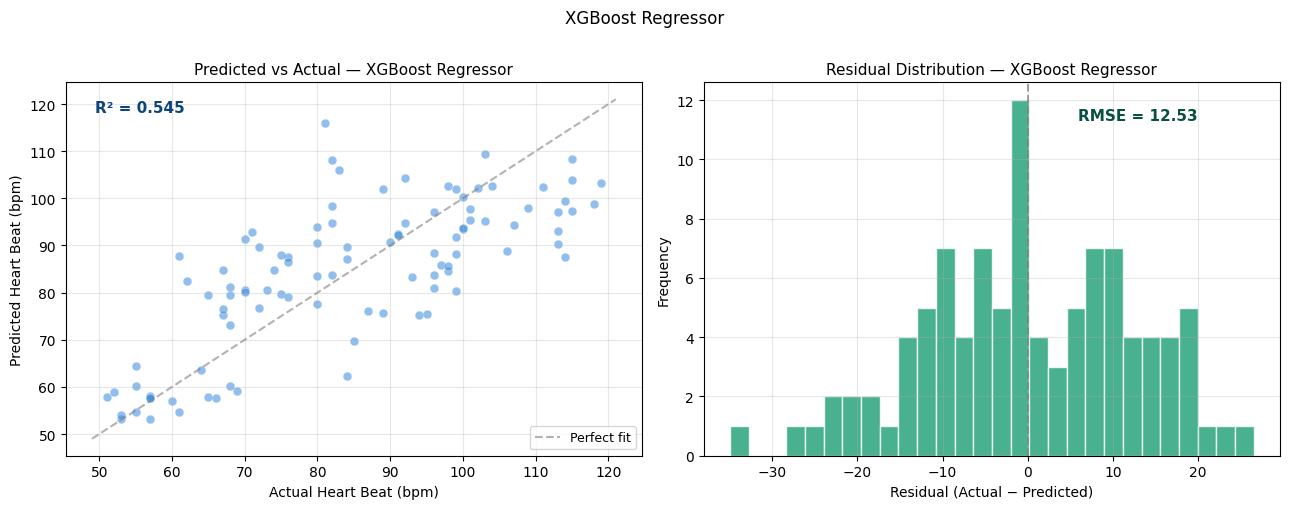



  KNN Regressor (k=10, distance weighted)  —  Regression Report
  R²   (R-squared)        : 0.4590
  MAE  (Mean Abs Error)   : 11.0009
  MSE  (Mean Sq Error)    : 186.4595
  RMSE (Root Mean Sq Err) : 13.6550
  RAE  (Rel Abs Error)    : 0.6884  ✓ beats mean baseline


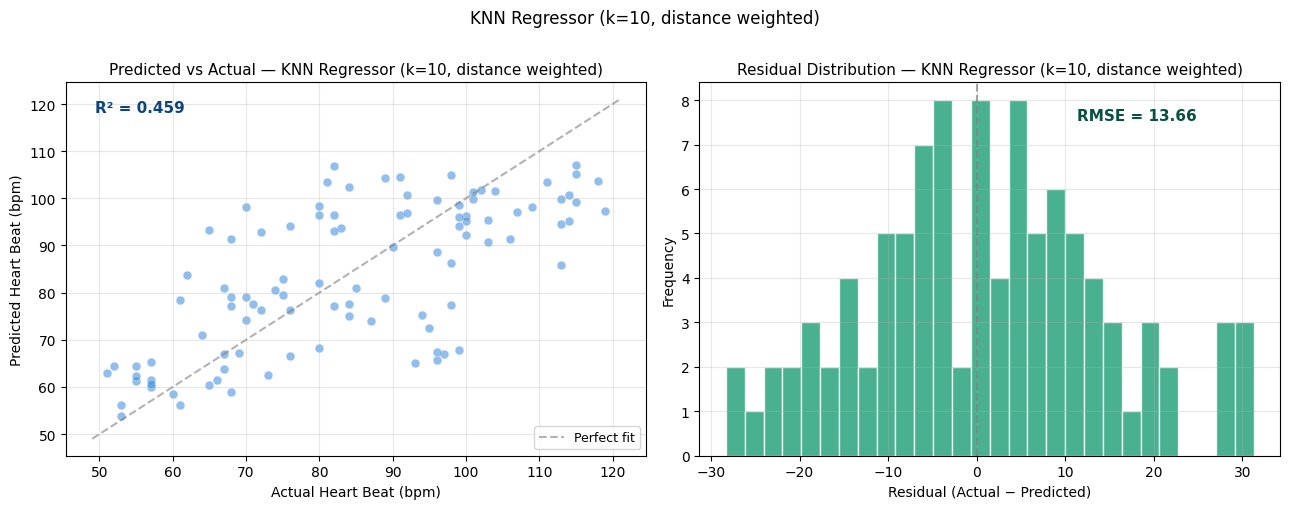



  Linear Regression (baseline)  —  Regression Report
  R²   (R-squared)        : 0.4946
  MAE  (Mean Abs Error)   : 11.0304
  MSE  (Mean Sq Error)    : 174.1923
  RMSE (Root Mean Sq Err) : 13.1982
  RAE  (Rel Abs Error)    : 0.6903  ✓ beats mean baseline


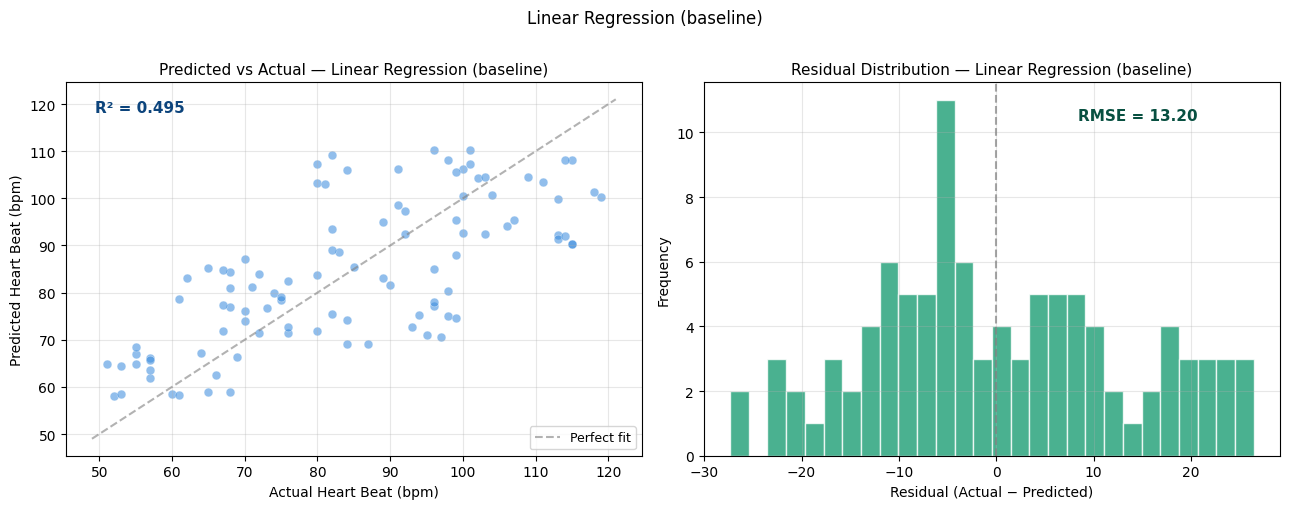

In [33]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# ── 1. Gradient Boosting — tuned (no max_features/subsample on small dataset)
gb_reg = GradientBoostingRegressor(
    n_estimators=800, learning_rate=0.02, max_depth=4,
    min_samples_leaf=3, min_samples_split=5,
    loss='huber', alpha=0.9, random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)
evaluate_regressor(gb_reg, X_test_reg, y_test_reg,
                   model_name='Gradient Boosting Regressor')

# ── 2. Random Forest — tuned
rf_reg = RandomForestRegressor(
    n_estimators=600, max_depth=None, max_features=0.8,
    min_samples_leaf=2, min_samples_split=4,
    max_samples=0.85, oob_score=True, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
print(f"  RF OOB R²: {rf_reg.oob_score_:.4f}")
evaluate_regressor(rf_reg, X_test_reg, y_test_reg,
                   model_name='Random Forest Regressor')

# ── 3. RidgeCV — auto-finds best alpha via 10-fold CV
ridge_reg = RidgeCV(
    alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], cv=10, scoring='r2')
ridge_reg.fit(X_train_reg, y_train_reg)
print(f"  Best Ridge alpha (CV): {ridge_reg.alpha_:.4f}")
evaluate_regressor(ridge_reg, X_test_reg, y_test_reg,
                   model_name='RidgeCV (auto alpha)')

# ── 4. XGBoost — L1 removed, all features used
xgb_reg = XGBRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=5,
    subsample=0.9, colsample_bytree=1.0,
    reg_alpha=0.0, reg_lambda=2.0,
    min_child_weight=3, gamma=0.1,
    tree_method='hist', random_state=42, verbosity=0)
xgb_reg.fit(X_train_reg, y_train_reg,
            eval_set=[(X_test_reg, y_test_reg)], verbose=False)
evaluate_regressor(xgb_reg, X_test_reg, y_test_reg,
                   model_name='XGBoost Regressor')

# ── 5. KNN — distance weighting (critical improvement from uniform)
knn_reg = KNeighborsRegressor(
    n_neighbors=10, weights='distance', algorithm='ball_tree', leaf_size=20)
knn_reg.fit(X_train_reg, y_train_reg)
evaluate_regressor(knn_reg, X_test_reg, y_test_reg,
                   model_name='KNN Regressor (k=10, distance weighted)')

# ── 6. Linear Regression (baseline)
linear_reg = LinearRegression()
linear_reg.fit(X_train_reg, y_train_reg)
evaluate_regressor(linear_reg, X_test_reg, y_test_reg,
                   model_name='Linear Regression (baseline)')

### 6.1 Regression comparison table

In [34]:
reg_models = {
    'Gradient Boosting' : gb_reg,
    'Random Forest'     : rf_reg,
    'RidgeCV'           : ridge_reg,
    'XGBoost'           : xgb_reg,
    'KNN'               : knn_reg,
    'Linear Regression' : linear_reg,
}

reg_rows = []
for name, mdl in reg_models.items():
    yp   = mdl.predict(X_test_reg).flatten()
    yt   = y_test_reg.flatten()
    r2   = r2_score(yt, yp)
    mae  = mean_absolute_error(yt, yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    denom = np.sum(np.abs(yt - yt.mean()))
    rae  = np.sum(np.abs(yt - yp)) / denom if denom != 0 else 0
    reg_rows.append({'Model':name, 'R²':round(r2,4), 'MAE':round(mae,4),
                     'MSE':round(mse,4), 'RMSE':round(rmse,4), 'RAE':round(rae,4)})

df_reg = pd.DataFrame(reg_rows).set_index('Model')

def style_reg(col):
    best = col == col.max() if col.name == 'R²' else col == col.min()
    return ['background-color:#d4edda;font-weight:bold' if v else '' for v in best]

print("\n Regression — All Models Comparison")
display(df_reg.style.apply(style_reg).format('{:.4f}')
        .set_caption("Regression Model Comparison — Heart Beat Prediction"))


 Regression — All Models Comparison


,R²,MAE,MSE,RMSE,RAE
Model,,,,,
Gradient Boosting,0.5179,10.3937,166.1584,12.8902,0.6504
Random Forest,0.5974,9.7849,138.7578,11.7796,0.6123
RidgeCV,0.4952,11.0423,173.9743,13.1899,0.6910
XGBoost,0.5448,10.2240,156.8844,12.5254,0.6398
KNN,0.4590,11.0009,186.4595,13.6550,0.6884
Linear Regression,0.4946,11.0304,174.1923,13.1982,0.6903


### 6.2 Regression visualisations

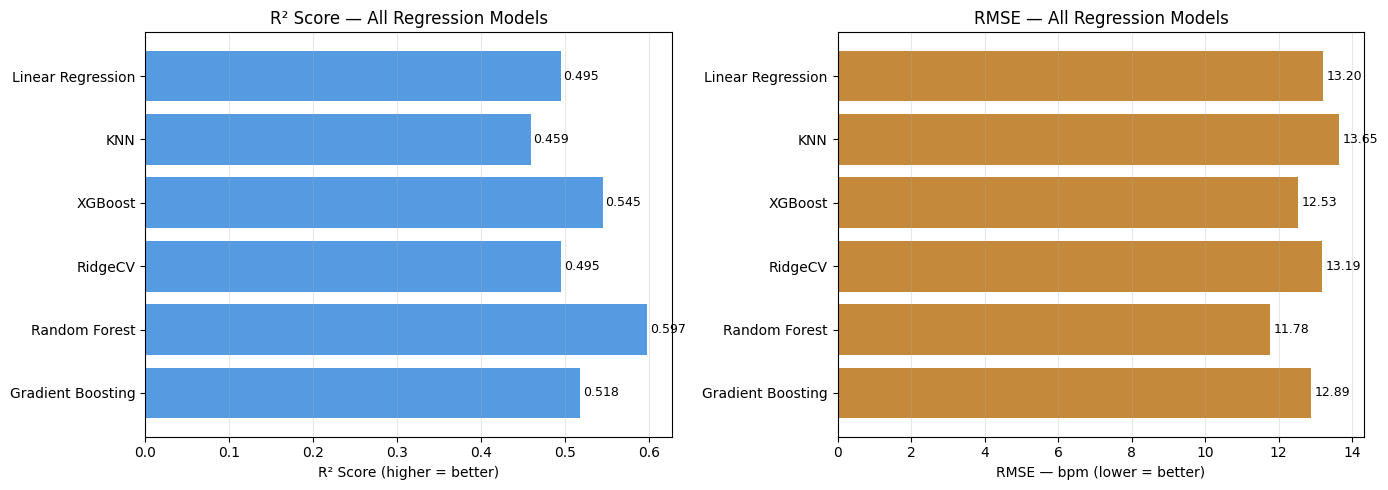

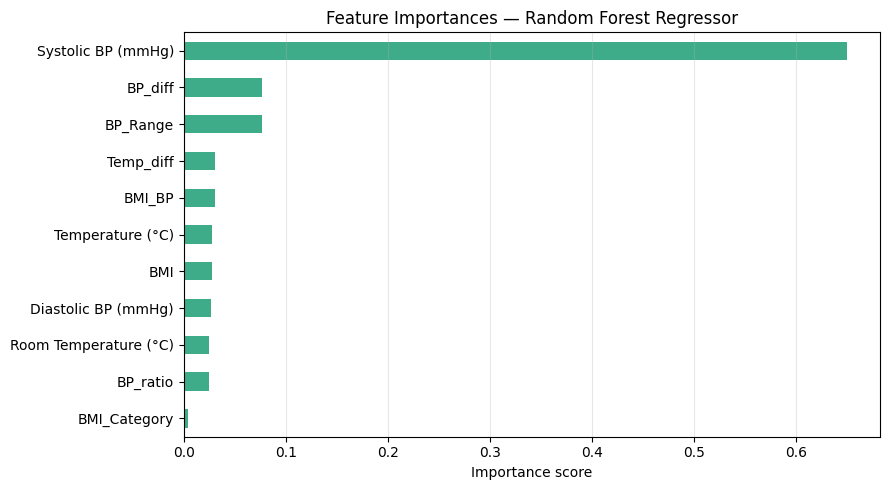

In [35]:
# R² comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(df_reg.index, df_reg['R²'], color='#378ADD', alpha=0.85)
axes[0].set_xlabel('R² Score (higher = better)')
axes[0].set_title('R² Score — All Regression Models', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_reg['R²']):
    axes[0].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(df_reg.index, df_reg['RMSE'], color='#BA7517', alpha=0.85)
axes[1].set_xlabel('RMSE — bpm (lower = better)')
axes[1].set_title('RMSE — All Regression Models', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_reg['RMSE']):
    axes[1].text(v+0.1, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

# Best model feature importance (Random Forest)
feat_imp = pd.Series(rf_reg.feature_importances_,
                     index=new_features.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', color='#1D9E75', alpha=0.85, ax=ax)
ax.set_title("Feature Importances — Random Forest Regressor", fontsize=12)
ax.set_xlabel("Importance score")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()